
        BEAM SEARCH

Level 0
Current Beam: ['S']
Candidates (node, heuristic): [('B', 3), ('C', 5), ('A', 6)]
Selected for next beam: ['B', 'C']
Discarded in this step: ['A']

Level 1
Current Beam: ['B', 'C']
Candidates (node, heuristic): [('F', 2), ('H', 3), ('G', 6), ('I', 8)]
Selected for next beam: ['F', 'H']
Discarded in this step: ['G', 'I']

Level 2
Current Beam: ['F', 'H']

Goal Found!
Final Path: S -> B -> F


/tmp/ipykernel_873/3173782084.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


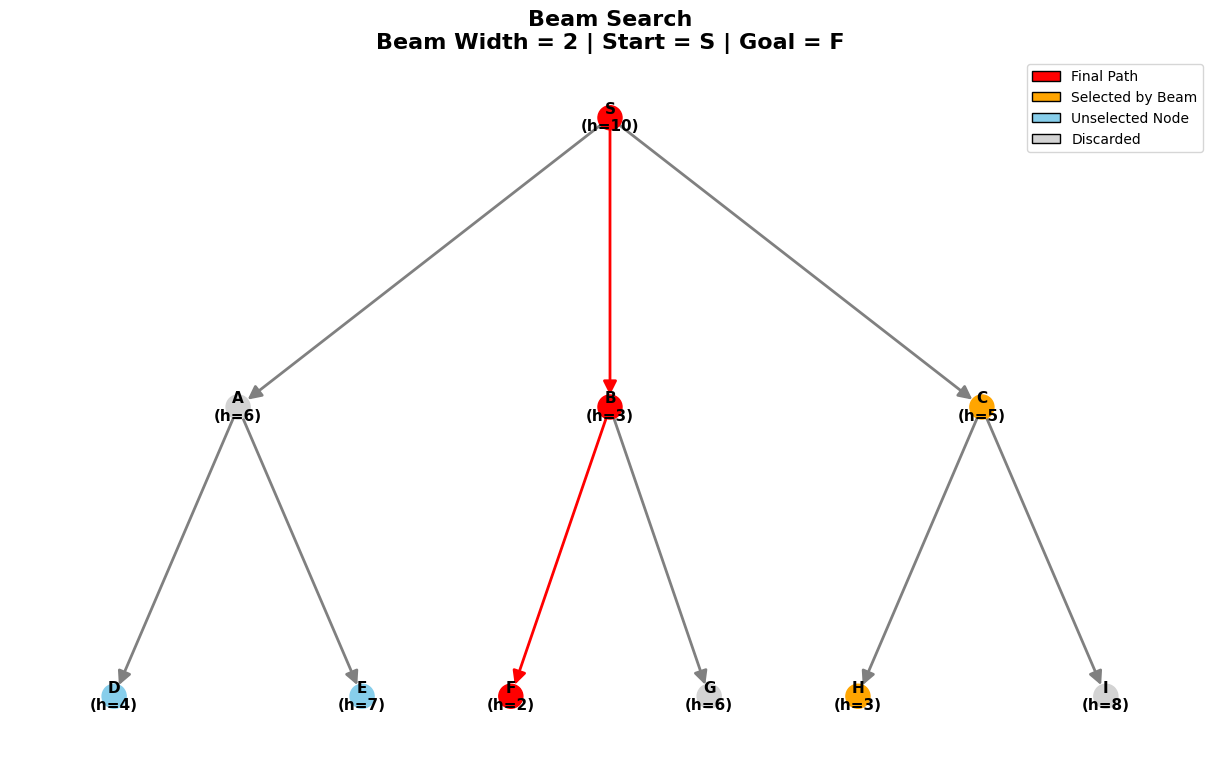

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
def beam_search(graph, heuristic, start, goal, beam_width):
    parent = {start: None}
    beam = [start]
    selected_nodes = {start}
    discarded_nodes = set()
    expanded_nodes = set()

    print("\n==============================")
    print("        BEAM SEARCH")
    print("==============================")
    level = 0

    while beam:
        print(f"\nLevel {level}")
        print("Current Beam:", beam)

        if goal in beam:
            print("\nGoal Found!")
            path = []
            current = goal
            while current is not None:
                path.append(current)
                current = parent.get(current)
            path.reverse()
            print("Final Path:", " -> ".join(path))
            return path, selected_nodes, discarded_nodes, expanded_nodes

        current_level_candidates = []
        for node in beam:
            expanded_nodes.add(node)
            for neighbour in graph.get(node, []):
                if neighbour not in selected_nodes and neighbour not in discarded_nodes:
                    current_level_candidates.append((neighbour, heuristic[neighbour]))
                    parent[neighbour] = node
        unique_candidates = []
        seen_nodes_in_candidates = set()
        for node, h_val in current_level_candidates:
            if node not in seen_nodes_in_candidates:
                unique_candidates.append((node, h_val))
                seen_nodes_in_candidates.add(node)
        unique_candidates.sort(key=lambda x: x[1])
        print("Candidates (node, heuristic):", unique_candidates)
        next_beam_tuples = unique_candidates[:beam_width]
        discarded_tuples = unique_candidates[beam_width:]

        next_beam = [node for node, h_val in next_beam_tuples]
        discarded_current_step = [node for node, h_val in discarded_tuples]

        discarded_nodes.update(discarded_current_step)
        selected_nodes.update(next_beam)
        beam = next_beam
        level += 1
        print("Selected for next beam:", beam)
        print("Discarded in this step:", discarded_current_step)
    print("\nGoal could not be reached.")
    return None, selected_nodes, discarded_nodes, expanded_nodes
graph = {
    'S': ['A', 'B', 'C'],
    'A': ['D', 'E'],
    'B': ['F', 'G'],
    'C': ['H', 'I'],
    'D': [],
    'E': [],
    'F': [],
    'G': [],
    'H': [],
    'I': []
}
heuristic = {
    'S': 10,
    'A': 6,
    'B': 3,
    'C': 5,
    'D': 4,
    'E': 7,
    'F': 2,
    'G': 6,
    'H': 3,
    'I': 8
}
start = 'S'
goal = 'F'
beam_width = 2
path, selected_nodes, discarded_nodes, expanded_nodes = beam_search(
    graph,
    heuristic,
    start,
    goal,
    beam_width
)
G = nx.DiGraph()
for node in graph:
    G.add_node(node)
    for neighbour in graph[node]:
        G.add_edge(node, neighbour)
pos = {
    'S': (0, 3),
    'A': (-3, 2),
    'B': (0, 2),
    'C': (3, 2),
    'D': (-4, 1),
    'E': (-2, 1),
    'F': (-0.8, 1),
    'G': (0.8, 1),
    'H': (2, 1),
    'I': (4, 1)
}
node_colors = []
for node in G.nodes():
    if path and node in path:
        node_colors.append("red")
    elif node in selected_nodes:
        node_colors.append("orange")
    elif node in discarded_nodes:
        node_colors.append("lightgray")
    else:
        node_colors.append("skyblue")
edge_colors = []
for edge in G.edges():
    u, v = edge
    if path and u in path and v in path:
        valid = False
        for i in range(len(path) - 1):
            if path[i] == u and path[i + 1] == v:
                valid = True
                break
        if valid:
            edge_colors.append("red")
        else:
            edge_colors.append("gray")
    else:
        edge_colors.append("gray")
labels = {}
for node in G.nodes():
    labels[node] = f"{node}\n(h={heuristic[node]})"
plt.figure(figsize=(12, 7))
nx.draw(
    G,
    pos,
    node_color=node_colors,
    edge_color=edge_colors,
    arrows=True,
    arrowsize=20,
    width=2,
    with_labels=False
nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=11,
    font_weight="bold"
)
plt.title(
    f"Beam Search\nBeam Width = {beam_width} | Start = {start} | Goal = {goal}",
    fontsize=16,
    fontweight="bold"
)

legend_elements = [
    Patch(
        facecolor="red",
        edgecolor="black",
        label="Final Path"
    ),
    Patch(
        facecolor="orange",
        edgecolor="black",
        label="Selected by Beam"
    ),
    Patch(
        facecolor="skyblue",
        edgecolor="black",
        label="Unselected Node"
    ),
    Patch(
        facecolor="lightgray",
        edgecolor="black",
        label="Discarded"
    )
]
plt.legend(
    handles=legend_elements,
    loc="upper right"
)
plt.axis("off")
plt.tight_layout()
plt.show()